# Catalog Cleaning: Products Catalog
Clean `category` and `is_prime_eligible` in the catalog file, then save a cleaned copy.

## 1. Load Catalog File and Inspect Columns
Read the raw catalog, confirm shape, and list columns.

In [20]:
from pathlib import Path
import pandas as pd

raw_path = (Path.cwd().parent / "data" / "raw" / "amazon_india_products_catalog.csv").resolve()

if not raw_path.exists():
    raise FileNotFoundError(f"Catalog file not found: {raw_path}")

catalog_df = pd.read_csv(raw_path)
print(f"Catalog shape: {catalog_df.shape}")
print("Catalog columns:")
for col in catalog_df.columns:
    print(f"- {col}")

Catalog shape: (2004, 11)
Catalog columns:
- product_id
- product_name
- category
- subcategory
- brand
- base_price_2015
- weight_kg
- rating
- is_prime_eligible
- launch_year
- model


In [21]:
# Inspect category right after loading
if "category" not in catalog_df.columns:
    raise KeyError("Expected column 'category' was not found in the catalog file.")

print("Category sample values:")
print(catalog_df["category"].head(10))

print("\nCategory value counts (top 20, raw):")
print(catalog_df["category"].value_counts(dropna=False).head(20))

print("\nCategory null rate (raw):")
print(catalog_df["category"].isna().mean())

Category sample values:
0    Electronics
1    Electronics
2    Electronics
3    Electronics
4    Electronics
5    Electronics
6    Electronics
7    Electronics
8    Electronics
9    Electronics
Name: category, dtype: str

Category value counts (top 20, raw):
category
Electronics    2004
Name: count, dtype: int64

Category null rate (raw):
0.0


In [22]:
# Grouped unique categories
print("Unique category values (grouped):")
print(
    catalog_df
    .groupby("category", dropna=False)
    .size()
    .sort_values(ascending=False)
)

Unique category values (grouped):
category
Electronics    2004
dtype: int64


In [23]:
# Inspect is_prime_eligible right after loading
if "is_prime_eligible" not in catalog_df.columns:
    raise KeyError("Expected column 'is_prime_eligible' was not found in the catalog file.")

print("is_prime_eligible sample values:")
print(catalog_df["is_prime_eligible"].head(10))

print("\nis_prime_eligible value counts (raw):")
print(catalog_df["is_prime_eligible"].value_counts(dropna=False))

print("\nis_prime_eligible null rate (raw):")
print(catalog_df["is_prime_eligible"].isna().mean())

is_prime_eligible sample values:
0     True
1     True
2     True
3     True
4     True
5     True
6    False
7    False
8     True
9     True
Name: is_prime_eligible, dtype: bool

is_prime_eligible value counts (raw):
is_prime_eligible
True     1654
False     350
Name: count, dtype: int64

is_prime_eligible null rate (raw):
0.0


In [24]:
# Inspect subcategory
if "subcategory" not in catalog_df.columns:
    print("Column 'subcategory' was not found in the catalog file.")
else:
    print("Subcategory sample values:")
    print(catalog_df["subcategory"].head(10))
    
    print("\nSubcategory value counts (top 20, raw):")
    print(catalog_df["subcategory"].value_counts(dropna=False).head(20))
    
    print("\nSubcategory null rate (raw):")
    print(catalog_df["subcategory"].isna().mean())
    
    print("\nTotal unique subcategories:")
    print(catalog_df["subcategory"].nunique())

Subcategory sample values:
0    Smartphones
1    Smartphones
2    Smartphones
3    Smartphones
4    Smartphones
5    Smartphones
6    Smartphones
7    Smartphones
8    Smartphones
9    Smartphones
Name: subcategory, dtype: str

Subcategory value counts (top 20, raw):
subcategory
Smartphones           1518
Laptops                155
Audio                  123
Smart Watch            102
Tablets                 78
TV & Entertainment      28
Name: count, dtype: int64

Subcategory null rate (raw):
0.0

Total unique subcategories:
6


In [25]:
# Inspect base_price_2015 before outlier correction
price_col = "base_price_2015"
if price_col not in catalog_df.columns:
    raise KeyError(f"Expected column '{price_col}' was not found in the catalog file.")

print(f"{price_col} sample values:")
print(catalog_df[price_col].head(10))

print(f"\n{price_col} summary:")
print(catalog_df[price_col].describe())

print(f"\n{price_col} quantiles:")
print(catalog_df[price_col].quantile([0.01, 0.05, 0.5, 0.95, 0.99]))

base_price_2015 sample values:
0    190469.10
1    158424.89
2    118141.16
3    211721.16
4    114806.24
5    209875.55
6    150746.20
7    180530.75
8    114096.63
9    173499.67
Name: base_price_2015, dtype: float64

base_price_2015 summary:
count      2004.000000
mean      73099.956751
std       68490.210618
min         841.750000
25%       22943.790000
50%       42182.740000
75%      106280.612500
max      323504.370000
Name: base_price_2015, dtype: float64

base_price_2015 quantiles:
0.01      4534.8864
0.05     12147.5160
0.50     42182.7400
0.95    206660.8385
0.99    300662.3859
Name: base_price_2015, dtype: float64


## 1.1 Univariate Analysis (base_price_2015)
Quick distribution view using histogram and boxplot.

In [26]:
import matplotlib.pyplot as plt

price_col = "base_price_2015"

price_series = catalog_df[price_col].dropna()

print(f"{price_col} summary:")
print(price_series.describe())
print(f"\n{price_col} skew:")
print(price_series.skew())

base_price_2015 summary:
count      2004.000000
mean      73099.956751
std       68490.210618
min         841.750000
25%       22943.790000
50%       42182.740000
75%      106280.612500
max      323504.370000
Name: base_price_2015, dtype: float64

base_price_2015 skew:
1.4214784317805014


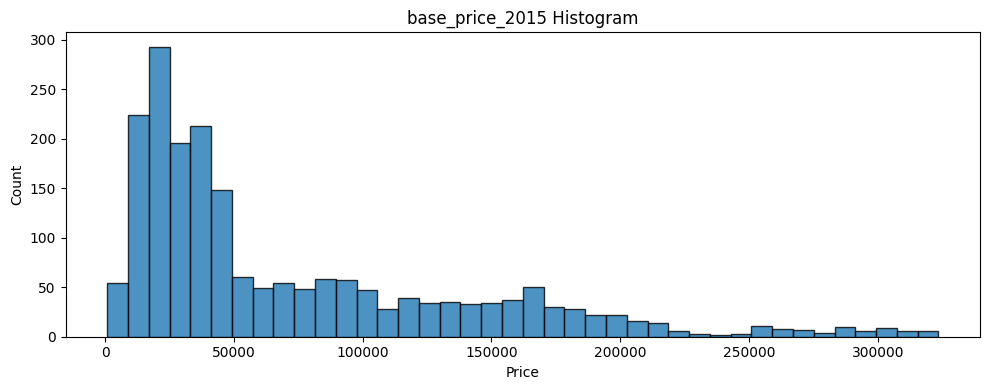

In [27]:
# Histogram
plt.figure(figsize=(10, 4))
plt.hist(price_series, bins=40, edgecolor="black", alpha=0.8)
plt.title(f"{price_col} Histogram")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

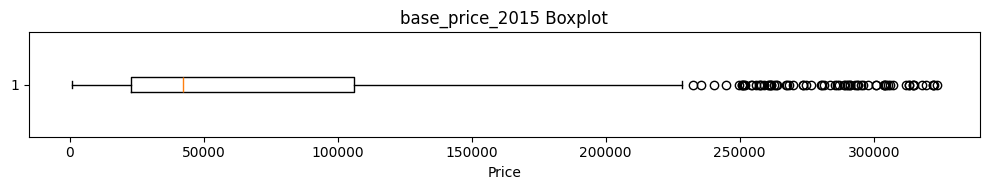

In [28]:
# Boxplot
plt.figure(figsize=(10, 2))
plt.boxplot(price_series, vert=False)
plt.title(f"{price_col} Boxplot")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

In [46]:
# Select relevant columns and group by brand
cols_to_select = ["base_price_2015", "subcategory", "product_name", "model", "brand", "launch_year"]
cols_available = [c for c in cols_to_select if c in catalog_df.columns]

if not cols_available:
    print("None of the requested columns were found.")
else:
    filtered_df = catalog_df[cols_available].copy()
    
    # Group by brand and show summary
    brand_summary = filtered_df.groupby("brand", dropna=False).agg({
        "base_price_2015": ["count", "mean", "median", "min", "max"],
        "product_name": "nunique",
    }).round(2)
    
    print("Brand-wise Summary:")
    print(brand_summary)
    print(f"\nTotal unique brands: {filtered_df['brand'].nunique()}")
    print(f"\nSample data:")
    display(filtered_df.head(10))

Brand-wise Summary:
               base_price_2015                                             \
                         count       mean     median       min        max   
brand                                                                       
ASUS                        20  124463.85  126120.37  40576.70  195667.79   
Acer                        19   90370.80   79255.95  26241.89  195339.15   
Alienware                   26  110184.38  114686.58  27365.52  197362.59   
Amazfit                     12   26881.05   28356.61   4715.07   45684.26   
Apple                      313  178710.69  176895.93   2973.41  323504.37   
Audio-Technica              16   13153.25   15191.99    841.75   24251.26   
Boat                        15   11133.64   11187.99   2567.50   20634.14   
Dell                        16  113361.14  118826.44  29350.42  180549.64   
Fire-Boltt                  15   27784.64   28668.34   4472.99   49650.99   
Fitbit                      11   30966.84   38746.39   2

,base_price_2015,subcategory,product_name,model,brand,launch_year
0,190469.10,Smartphones,Apple iPhone 6 16GB Black,iPhone 6,Apple,2015
1,158424.89,Smartphones,Apple iPhone 6 32GB Black,iPhone 6,Apple,2015
2,118141.16,Smartphones,Apple iPhone 6 64GB Black,iPhone 6,Apple,2015
3,211721.16,Smartphones,Apple iPhone 6 16GB White,iPhone 6,Apple,2015
4,114806.24,Smartphones,Apple iPhone 6 32GB White,iPhone 6,Apple,2015
5,209875.55,Smartphones,Apple iPhone 6 16GB Blue,iPhone 6,Apple,2015
6,150746.20,Smartphones,Apple iPhone 6 32GB Blue,iPhone 6,Apple,2015
7,180530.75,Smartphones,Apple iPhone 6 16GB Gold,iPhone 6,Apple,2015
8,114096.63,Smartphones,Apple iPhone 6 Plus 16GB Black,iPhone 6 Plus,Apple,2015
9,173499.67,Smartphones,Apple iPhone 6 Plus 32GB Black,iPhone 6 Plus,Apple,2015


In [48]:

# Identify unique launch years
if "launch_year" not in catalog_df.columns:
    print("Column 'launch_year' was not found in the catalog file.")
else:
    print("Launch Year distribution:")
    print(catalog_df["launch_year"].value_counts(dropna=False).sort_index())
    
    print(f"\nTotal unique launch years: {catalog_df['launch_year'].nunique()}")
    print(f"Launch year range: {catalog_df['launch_year'].min()} to {catalog_df['launch_year'].max()}")
    print(f"Launch year null count: {catalog_df['launch_year'].isna().sum()}")


Launch Year distribution:
launch_year
2015    164
2016    148
2017    156
2018    188
2019    208
2020    205
2021    193
2022    177
2023    189
2024    195
2025    181
Name: count, dtype: int64

Total unique launch years: 11
Launch year range: 2015 to 2025
Launch year null count: 0


In [50]:

# Identify unique models
if "model" not in catalog_df.columns:
    print("Column 'model' was not found in the catalog file.")
else:
    print("Model distribution (top 20):")
    print(catalog_df["model"].value_counts(dropna=False).head(20))
    
    print(f"\nTotal unique models: {catalog_df['model'].nunique()}")
    print(f"Model null count: {catalog_df['model'].isna().sum()}")
    print(f"Model null rate: {catalog_df['model'].isna().mean():.2%}")


Model distribution (top 20):
model
Neckband             23
Inspiron             22
Ultrabook            22
Earbuds              22
Gaming               21
Bluetooth Speaker    21
Watch                21
Sports Watch         21
Fitness Band         21
Pavilion             20
Tracker              20
Headphones           19
TWS                  19
Gaming Headset       19
Band                 19
ThinkPad             18
Aspire               18
VivoBook             17
MacBook              17
Phone (2a)           16
Name: count, dtype: int64

Total unique models: 247
Model null count: 0
Model null rate: 0.00%



## 2. Correct Price Outliers (Per Brand)
STEP 1: Detect statistical outliers (IQR within each brand).
STEP 2: Compute ratio to brand median.
STEP 3: Combine both conditions – correct only when statistical outlier AND exceeds 5× brand median.
STEP 4: Replace with brand median and create tracking column.


In [ ]:
catalog_df["base_price_2015"] = catalog_df["base_price_2015"]

## 3. Save Cleaned Copy
Save the catalog after outlier corrections.

In [56]:

# STEP 1: Detect Statistical Outliers (Per Brand using IQR)
price_col = "base_price_2015"

def is_statistical_outlier(series):
    """Mark values outside IQR bounds as statistical outliers."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (series < lower_bound) | (series > upper_bound)

catalog_df["is_stat_outlier_brand"] = catalog_df.groupby("brand")[price_col].transform(is_statistical_outlier)

print(f"Statistical outliers (per brand IQR): {catalog_df['is_stat_outlier_brand'].sum()}")


Statistical outliers (per brand IQR): 31


In [57]:

# STEP 2: Compute Brand Median and Ratio
catalog_df["brand_median"] = catalog_df.groupby("brand")[price_col].transform("median")
catalog_df["ratio_to_brand_median"] = catalog_df[price_col] / catalog_df["brand_median"]

print(f"Brand median computed for {catalog_df['brand'].nunique()} brands")
print(f"\nRatio to brand median stats:")
print(catalog_df["ratio_to_brand_median"].describe())


Brand median computed for 29 brands

Ratio to brand median stats:
count    2004.000000
mean        1.016928
std         0.443776
min         0.012642
25%         0.708524
50%         1.000000
75%         1.318733
max         3.028665
Name: ratio_to_brand_median, dtype: float64


In [58]:

# STEP 3: Combine Both Conditions
# Correct ONLY when BOTH conditions are met:
# 1. Is a statistical outlier (per brand IQR)
# 2. Exceeds 5× brand median

SUSPICIOUS_THRESHOLD = 5.0

catalog_df["ratio_exceeds_threshold"] = catalog_df["ratio_to_brand_median"] > SUSPICIOUS_THRESHOLD
catalog_df["needs_correction"] = (
    catalog_df["is_stat_outlier_brand"] & 
    catalog_df["ratio_exceeds_threshold"]
)

print(f"Statistical outliers: {catalog_df['is_stat_outlier_brand'].sum()}")
print(f"Ratio exceeds {SUSPICIOUS_THRESHOLD}×: {catalog_df['ratio_exceeds_threshold'].sum()}")
print(f"Both conditions met (needs correction): {catalog_df['needs_correction'].sum()}")


Statistical outliers: 31
Ratio exceeds 5.0×: 0
Both conditions met (needs correction): 0


In [59]:

# STEP 4: Create Tracking Column and Apply Correction
# Create a column to track the corrected price (copy original, then replace outliers)
catalog_df["price_corrected"] = catalog_df[price_col].copy()
catalog_df.loc[catalog_df["needs_correction"], "price_corrected"] = (
    catalog_df.loc[catalog_df["needs_correction"], "brand_median"]
)

# Create a correction status column for transparency
catalog_df["correction_status"] = "original"
catalog_df.loc[catalog_df["needs_correction"], "correction_status"] = "corrected_to_brand_median"

print(f"Corrected prices created:")
print(f"  Original records: {(catalog_df['correction_status'] == 'original').sum()}")
print(f"  Corrected records: {(catalog_df['correction_status'] == 'corrected_to_brand_median').sum()}")

# Show sample of corrected records
if catalog_df["needs_correction"].any():
    print(f"\nSample of corrected records:")
    sample_cols = ["product_name", "brand", price_col, "brand_median", "ratio_to_brand_median", "correction_status"]
    display(catalog_df.loc[catalog_df["needs_correction"], sample_cols].head(10))


Corrected prices created:
  Original records: 2004
  Corrected records: 0


In [60]:

# Check specific record: Apple iPhone 13 128GB Black
apple_iphone13 = catalog_df[
    (catalog_df["brand"] == "Apple") & 
    (catalog_df["product_name"].str.contains("iPhone 13 128GB Black", case=False, na=False))
]

if len(apple_iphone13) > 0:
    print("Found Apple iPhone 13 128GB Black:")
    display(apple_iphone13[[
        "product_name", "brand", "base_price_2015", "brand_median", 
        "ratio_to_brand_median", "is_stat_outlier_brand", "needs_correction", "correction_status"
    ]])
    
    # Now check Apple brand pricing context
    print("\n\nApple Brand Pricing Context:")
    apple_data = catalog_df[catalog_df["brand"] == "Apple"]
    print(f"Total Apple products: {len(apple_data)}")
    print(f"\nApple price statistics:")
    print(apple_data[price_col].describe())
    print(f"\nApple price range: ₹{apple_data[price_col].min():,.2f} to ₹{apple_data[price_col].max():,.2f}")
    print(f"Apple brand median: ₹{apple_data[price_col].median():,.2f}")
    
    # Check the specific record's position
    specific_price = apple_iphone13[price_col].values[0]
    apple_median = apple_data[price_col].median()
    ratio = specific_price / apple_median
    
    print(f"\n\n✓ ASSESSMENT:")
    print(f"Product price: ₹{specific_price:,.2f}")
    print(f"Apple median: ₹{apple_median:,.2f}")
    print(f"Ratio to Apple median: {ratio:.2f}×")
    
    if ratio > 3:
        print(f"\n⚠️ CONCERN: Price is {ratio:.2f}× the Apple brand median (HIGH - potential error)")
    elif ratio > 2:
        print(f"\n⚠️ CONCERN: Price is {ratio:.2f}× the Apple brand median (ELEVATED - may warrant review)")
    elif ratio > 1.5:
        print(f"\n⚠️ WARNING: Price is {ratio:.2f}× the Apple brand median (somewhat elevated)")
    else:
        print(f"\n✓ ACCEPTABLE: Price is {ratio:.2f}× the Apple brand median")
else:
    print("Product not found. Searching for similar products...")
    apple_iphone13_partial = catalog_df[
        (catalog_df["brand"] == "Apple") & 
        (catalog_df["product_name"].str.contains("iPhone 13", case=False, na=False))
    ]
    if len(apple_iphone13_partial) > 0:
        print(f"Found {len(apple_iphone13_partial)} iPhone 13 variants:")
        display(apple_iphone13_partial[[
            "product_name", "brand", "base_price_2015"
        ]].head(10))


Found Apple iPhone 13 128GB Black:


,product_name,brand,base_price_2015,brand_median,ratio_to_brand_median,is_stat_outlier_brand,needs_correction,correction_status
795,Apple iPhone 13 128GB Black,Apple,261706.39,176895.93,1.479437,False,False,original




Apple Brand Pricing Context:
Total Apple products: 313

Apple price statistics:
count       313.000000
mean     178710.691182
std       72806.522806
min        2973.410000
25%      141369.370000
50%      176895.930000
75%      212508.660000
max      323504.370000
Name: base_price_2015, dtype: float64

Apple price range: ₹2,973.41 to ₹323,504.37
Apple brand median: ₹176,895.93


✓ ASSESSMENT:
Product price: ₹261,706.39
Apple median: ₹176,895.93
Ratio to Apple median: 1.48×

✓ ACCEPTABLE: Price is 1.48× the Apple brand median


In [61]:

# Smartphones Category Count
smartphones_count = catalog_df[catalog_df["subcategory"] == "Smartphones"].shape[0]
total_products = catalog_df.shape[0]
smartphones_pct = (smartphones_count / total_products) * 100

print(f"Smartphones Count: {smartphones_count}")
print(f"Total Products: {total_products}")
print(f"Smartphones Percentage: {smartphones_pct:.2f}%")

# Additional breakdown
print(f"\nSmartphones by Brand (top 10):")
smartphones_by_brand = catalog_df[catalog_df["subcategory"] == "Smartphones"].groupby("brand").size().sort_values(ascending=False)
print(smartphones_by_brand.head(10))


Smartphones Count: 1518
Total Products: 2004
Smartphones Percentage: 75.75%

Smartphones by Brand (top 10):
brand
Samsung     293
Apple       268
Xiaomi      223
OnePlus     205
Realme      173
Vivo        102
Oppo         98
iQOO         57
Nothing      54
Motorola     45
dtype: int64
